# Data Analysis

Thesis: Zeinab BagheriFard

Paper: Situated visualization towards Manufacturing Maintenance Training: scoping review, design and user study

In [ ]:
#Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Preparation

In [ ]:
# Preparation for merging
##Shared in all datasets:
COLUMNS_BASE = ['Scene', 'Participant']

##Extra columns each specific file contains, with their variables
###Completion time file should have: Completion Time
COLUMNS_COMPLETION = ["Completion Time"]
###NASA-TLX file should have the workload questions + final score
COLUMNS_NASA_TLX = ['Mental Demand', 'Physical Demand',
                    'Temporal Demand','Performance','Effort','Frustration',
                    'Sum', 'NASA-TLX Score']
###SSQ file should have the sickness symptoms + sub-scores + final score
COLUMNS_SSQ = ['General discomfort', 'Fatigue',
       'Headache', 'Eye strain', 'Difficulty focusing',
       'Increased salivation', 'Sweating', 'Nausea Level',
       'Difficulty concentrating', 'Fullness of head',
       'Blurred vision', 'Dizziness (eyes open)',
       'Dizziness (eyes closed)', 'Vertigo', 'Stomach awareness',
       'Burping', 'Sum1', 'Nausea', 'sum2', 'Oculomotor', 'sum3',
       'Disorientation', 'sum4', 'Sum5', 'SSQ Score']
###SUS file should have the SUS questions + SUS Score
COLUMNS_SUS = [
       'SUS:I think that I would like to use this system frequently.', 'Unnamed: 3',
       'SUS:I found the system unnecessarily complex. ', 'Unnamed: 5',
       'SUS:I thought the system was easy to use.  ', 'Unnamed: 7',
       'SUS:I think that I would need the support of a technical person to be able to use this system.   ', 'Unnamed: 9',
       'SUS:I found the various functions in this system were well integrated.  ', 'Unnamed: 11',
       'SUS:I thought there was too much inconsistency in this system  ', 'Unnamed: 13',
       'SUS:I would imagine that most people would learn to use this system very quickly.  ', 'Unnamed: 15',
       'SUS:I found the system very cumbersome to use.  ', 'Unnamed: 17',
       'SUS:I felt very confident using the system.  ', 'Unnamed: 19',
       'SUS:I needed to learn a lot of things before I could get going with this system.  ', 'Unnamed: 21',
       'SUS Score', 'SUS Points']

In [ ]:
# Merging all data in a single DataFrame
## Reading files and overwriting the column headers of each file using the headers I described

data_ct = pd.read_csv("CompletionTime.csv")
data_ct.columns = COLUMNS_BASE + COLUMNS_COMPLETION

data_nasa = pd.read_csv("Nasa.csv")
data_nasa.columns = COLUMNS_BASE + COLUMNS_NASA_TLX

data_ssq = pd.read_csv("SSQ.csv")
# data_ssq["Nausea"] = pd.to_numeric(data_ssq["Nausea"], errors="coerce")
# data_ssq = data_ssq.dropna(subset=["Nausea"])
data_ssq.columns = COLUMNS_BASE + COLUMNS_SSQ

data_sus = pd.read_csv("SUS.csv") # Removing the P01 from scene 3D
data_sus.columns = COLUMNS_BASE + COLUMNS_SUS
       

FileNotFoundError: [Errno 2] No such file or directory: 'CompletionTime.csv'

In [ ]:
##Merging all files in data
data = data_ct.copy()
data = pd.merge(left=data, right=data_nasa, on=COLUMNS_BASE)
data = pd.merge(left=data, right=data_ssq, on=COLUMNS_BASE)
data = pd.merge(left=data, right=data_sus, on=COLUMNS_BASE)

data

,Scene,Participant,Completion Time,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Sum,...,SUS:I would imagine that most people would learn to use this system very quickly.,Unnamed: 15,SUS:I found the system very cumbersome to use.,Unnamed: 17,SUS:I felt very confident using the system.,Unnamed: 19,SUS:I needed to learn a lot of things before I could get going with this system.,Unnamed: 21,SUS Score,SUS Points
0,2D,P01,99.09,3,3,1,10,2,1,20,...,4,3,2,3,4,3,2,3,82.5,33
1,2D,P02,137.66,4,3,2,10,1,1,21,...,5,4,1,4,5,4,1,4,100.0,40
2,2D,P03,101.41,2,1,1,10,2,1,17,...,3,2,1,4,4,3,2,3,87.5,35
3,2D,P04,112.35,2,1,3,8,3,4,21,...,4,3,2,3,5,4,3,2,82.5,33
4,2D,P05,166.27,5,1,1,10,1,1,19,...,5,4,1,4,5,4,1,4,100.0,40
5,2D,P06,185.52,3,2,1,9,3,1,19,...,5,4,1,4,5,4,1,4,97.5,39
6,2D,P07,120.60,5,8,5,9,6,1,34,...,4,3,1,4,4,3,1,4,87.5,35
7,2D,P08,230.42,3,3,2,8,6,1,23,...,4,3,2,3,4,3,2,3,72.5,29
8,2D,P09,203.27,2,2,1,10,9,1,25,...,4,3,4,1,5,4,4,1,67.5,27
9,2D,P10,170.39,3,4,4,9,3,2,25,...,5,4,2,3,4,3,1,4,75.0,30


In [ ]:
data['Scene'] = data['Scene'].replace({
                            "2D":"2D Label",
                            "3D":"3D Ghost"
                        })
data

,Scene,Participant,Completion Time,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Sum,...,SUS:I would imagine that most people would learn to use this system very quickly.,Unnamed: 15,SUS:I found the system very cumbersome to use.,Unnamed: 17,SUS:I felt very confident using the system.,Unnamed: 19,SUS:I needed to learn a lot of things before I could get going with this system.,Unnamed: 21,SUS Score,SUS Points
0,2D Label,P01,99.09,3,3,1,10,2,1,20,...,4,3,2,3,4,3,2,3,82.5,33
1,2D Label,P02,137.66,4,3,2,10,1,1,21,...,5,4,1,4,5,4,1,4,100.0,40
2,2D Label,P03,101.41,2,1,1,10,2,1,17,...,3,2,1,4,4,3,2,3,87.5,35
3,2D Label,P04,112.35,2,1,3,8,3,4,21,...,4,3,2,3,5,4,3,2,82.5,33
4,2D Label,P05,166.27,5,1,1,10,1,1,19,...,5,4,1,4,5,4,1,4,100.0,40
5,2D Label,P06,185.52,3,2,1,9,3,1,19,...,5,4,1,4,5,4,1,4,97.5,39
6,2D Label,P07,120.60,5,8,5,9,6,1,34,...,4,3,1,4,4,3,1,4,87.5,35
7,2D Label,P08,230.42,3,3,2,8,6,1,23,...,4,3,2,3,4,3,2,3,72.5,29
8,2D Label,P09,203.27,2,2,1,10,9,1,25,...,4,3,4,1,5,4,4,1,67.5,27
9,2D Label,P10,170.39,3,4,4,9,3,2,25,...,5,4,2,3,4,3,1,4,75.0,30


In [ ]:
##Storing the table(short format)
data.to_csv("data_short_format.csv",index=False)

Transforming to long format to facilitate filtering and analysis

In [ ]:
##Storing the table(long format): Keeping Scene and Participant and putting all other columns in 2 columns variable (the original column name) and value (the number).
df_long = data.melt(id_vars=["Scene","Participant"])
df_long

,Scene,Participant,variable,value
0,2D Label,P01,Completion Time,99.09
1,2D Label,P02,Completion Time,137.66
2,2D Label,P03,Completion Time,101.41
3,2D Label,P04,Completion Time,112.35
4,2D Label,P05,Completion Time,166.27
...,...,...,...,...
1339,3D Ghost,P08,SUS Points,32.00
1340,3D Ghost,P09,SUS Points,37.00
1341,3D Ghost,P10,SUS Points,40.00
1342,3D Ghost,P11,SUS Points,18.00


In [ ]:
df_long.to_csv("data_long_format.csv",index=False)

## Main Data Visualization

In [ ]:
data = pd.read_csv("data_long_format.csv")
data

,Scene,Participant,variable,value
0,2D Label,P01,Completion Time,99.09
1,2D Label,P02,Completion Time,137.66
2,2D Label,P03,Completion Time,101.41
3,2D Label,P04,Completion Time,112.35
4,2D Label,P05,Completion Time,166.27
...,...,...,...,...
1339,3D Ghost,P08,SUS Points,32.00
1340,3D Ghost,P09,SUS Points,37.00
1341,3D Ghost,P10,SUS Points,40.00
1342,3D Ghost,P11,SUS Points,18.00


In [ ]:
# Columns subgroups
#Groups metrics into categories for plotting
#Sets the main grouping variable, compare results by “Scene” (condition).
COLNAME_INDEP_VAR = 'Scene'

#Mapping labels displaying on the plot
COLS_SUBPLOTS = {
    "Task Completion Time (s)": ['Completion Time'],
    "Usability": ['SUS Score'],
    "Workload": ['NASA-TLX Score'],
    # "Discomfort": ['Nausea','Oculomotor','Disorientation','SSQ Score'],
    # "Memory Recall": [']
}
COLS_SUBPLOTS

{'Task Completion Time (s)': ['Completion Time'],
 'Usability': ['SUS Score'],
 'Workload': ['NASA-TLX Score']}

In [ ]:
#Group the data by Scene, calculate the mean of the values in each group
df.groupby(COLNAME_INDEP_VAR)['value'].agg('mean').reset_index()


,Scene,value
0,2D Label,151.054167
1,3D Ghost,138.425833


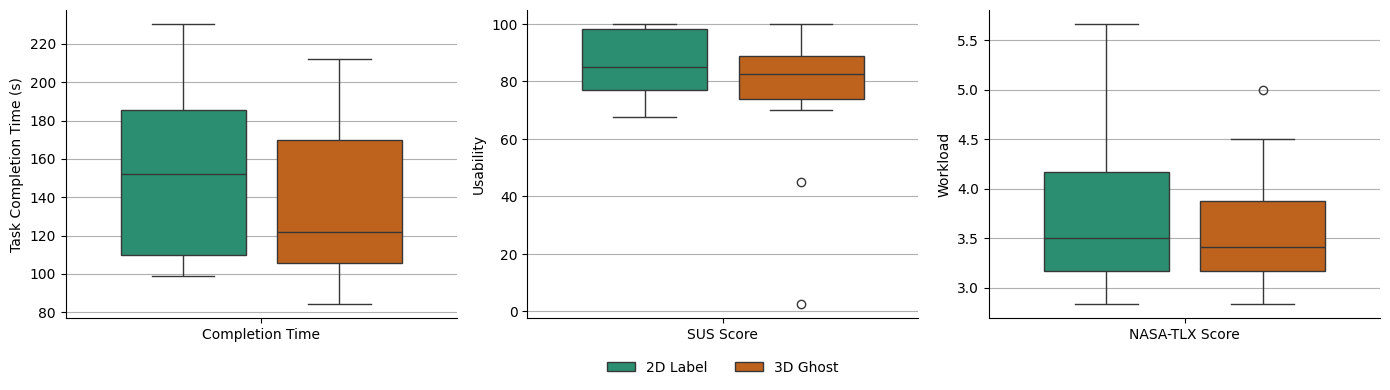

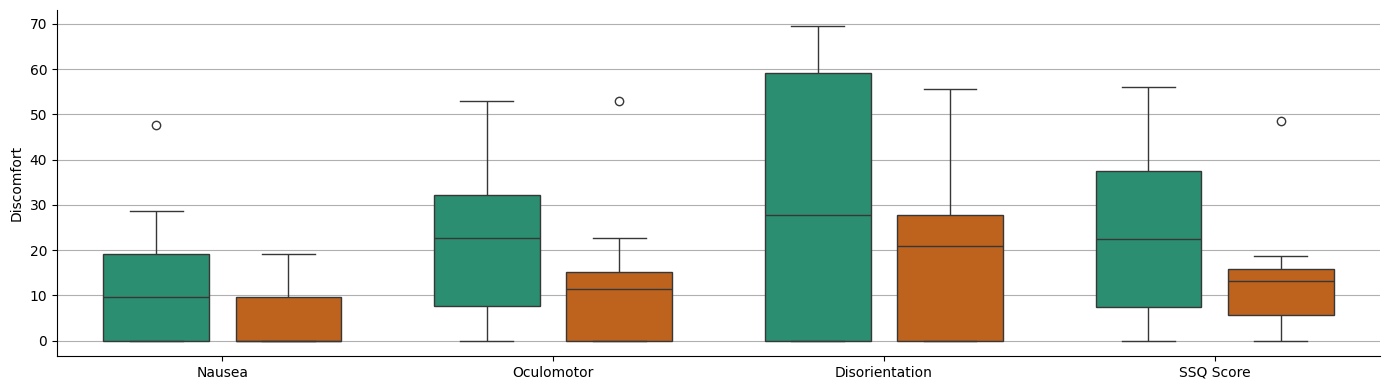

In [ ]:
#Create a figure with 3 empty plot areas to show them side by side
f, axes = plt.subplots(1,3, figsize=(14,4))
axes = axes.reshape(-1) # Accesses the axes in single list

for i,(label,colnames) in enumerate(COLS_SUBPLOTS.items()):
    ax = axes[i]
    #Filter the data to only to one metric at a time
    df = data[ data['variable'].isin(colnames) ]

    # https://matplotlib.org/stable/users/explain/colors/colormaps.html#qualitative
    PALETTE_NAME = "Dark2"
    with sns.color_palette(PALETTE_NAME):
        
        #Calculate summary numbers (mean + standard deviation)
        stats = df.groupby(COLNAME_INDEP_VAR)['value'].agg(mean="mean", sd="std").reset_index()
        #Draw the boxplot
        sns.boxplot(data=df, 
                    x="variable", y="value", hue=COLNAME_INDEP_VAR,
                    ax = ax, gap = .2
                    )
        ax.set(xlabel="", ylabel= label)

        # Legend
        if((i == 1) ):
            ax.legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', ncols=2,
                borderaxespad=0, labelcolor='black', fontsize='medium',
                frameon=False
                )
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        # Plot format
        ax.grid(axis='y')
        ax.set_axisbelow(True) # Solves grid lines drawn on top of barplot
        ax.spines['top'].set_visible(False)
        # ax.spines['bottom'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # ax.spines['left'].set_visible(False)
    
plt.savefig(f"img-results1.pdf", dpi=200, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()


# Discomfort: plot for the discomfort-related metrics

label = "Discomfort" 
colnames = ['Nausea','Oculomotor','Disorientation','SSQ Score']

f, axes = plt.subplots(1,1, figsize=(14,4))
ax = axes
df = data[ data['variable'].isin(colnames) ]

# https://matplotlib.org/stable/users/explain/colors/colormaps.html#qualitative
PALETTE_NAME = "Dark2"
with sns.color_palette(PALETTE_NAME):
    sns.boxplot(data=df, 
                x="variable", y="value", hue=COLNAME_INDEP_VAR,
                ax = ax, gap = .2)
    ax.set(xlabel="", ylabel= label)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Plot format
    ax.grid(axis='y')
    ax.set_axisbelow(True) # Solves grid lines drawn on top of barplot
    ax.spines['top'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)


plt.savefig(f"img-results2.pdf", dpi=200, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

